In [7]:
import env
import numpy as np

In [8]:
# Create the environment
environment = env.env()

In [9]:
# Reset the environment
environment.reset()

In [10]:
# Observe the first agent
observation = environment.observe('player_0')
print(observation)

{'observation': array([[0., 0., 2., 1., 2.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]]), 'action_mask': (array([1, 0, 0, 0], dtype=int8), array([0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int8))}


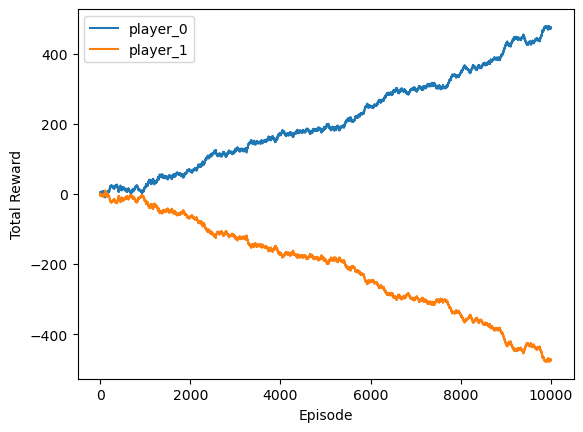

In [11]:
import random

# Initialize variables for training
num_episodes = 10000
reward_history = {
    'player_0': [],
    'player_1': []
}

for episode in range(num_episodes):
    environment.reset()
    episode_reward = 0

    for agent in environment.agent_iter():
        observation, reward, termination, truncation, info = environment.last()

        if termination or truncation:
            action = None
            # print(reward)
            reward_history[agent].append((reward + reward_history[agent][-1]) if len(reward_history[agent]) > 0 else reward)
            # print(environment.rewards)
        else:
            mask = observation["action_mask"]
            # this is where you would insert your policy
            action = environment.action_space(agent).sample(mask)

        environment.step(action)


    # print(f"Episode {episode + 1}: Total Reward: {episode_reward}")

environment.close()

# print(reward_history)

# Plot the reward history
import matplotlib.pyplot as plt

plt.plot(reward_history['player_0'], label='player_0')
plt.plot(reward_history['player_1'], label='player_1')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.legend()
plt.show()

